In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

categorical_columns = list(df.dtypes[df.dtypes== 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(" ", "_")

In [8]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu,9305-cdskc,1452-kiovk,6713-okomc,7892-pookp,6388-tabgu
gender,female,male,male,male,female,female,male,female,female,male
seniorcitizen,0,0,0,0,0,0,0,0,0,0
partner,yes,no,no,no,no,no,no,no,yes,no
dependents,no,no,no,no,no,no,yes,no,no,yes
tenure,1,34,2,45,2,8,22,10,28,62
phoneservice,no,yes,yes,no,yes,yes,yes,no,yes,yes
multiplelines,no_phone_service,no,no,no_phone_service,no,yes,yes,no_phone_service,yes,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic,fiber_optic,fiber_optic,dsl,fiber_optic,dsl
onlinesecurity,no,yes,yes,yes,no,no,no,yes,no,yes


In [18]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [19]:
df['totalcharges'] = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [22]:
(df.churn == 'yes').astype(int).head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [23]:
df.churn = (df.churn == 'yes').astype(int)

In [25]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1


## 3.3 Setting up the validation framework

In [38]:
from sklearn.model_selection import train_test_split

df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=1, shuffle=True)

In [39]:
df_train, df_val = train_test_split(df_train_val,test_size=0.25, random_state=1, shuffle=True)


In [40]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [41]:
df_train.reset_index(drop=True,inplace=True)
df_val.reset_index(drop=True,inplace=True)
df_test.reset_index(drop=True,inplace=True)

In [42]:
y_train = df_train['churn'].values
del df_train['churn']

y_val = df_val['churn'].values
del df_val['churn']

y_test = df_test['churn'].values
del df_test['churn']

## 3.04 Exploratory Data Analysis

In [46]:
df_train_val.reset_index(drop=True, inplace=True)

In [53]:
df_train_val.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [56]:
global_churn_rate = df_train_val.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [58]:
numerical = ["tenure", "monthlycharges", "totalcharges"]

In [59]:
df_train_val.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [61]:
categorical = [
    'gender', 'seniorcitizen', 'partner', 'dependents',
    'phoneservice', 'multiplelines', 'internetservice',
    'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
    'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
    'paymentmethod',
    ]

In [62]:
df_train_val[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.05 Feature Importance: Churn Rate and Risk Ratio

In [66]:
churn_female = df_train_val[df_train_val.gender=='female'].churn.mean()
churn_male = df_train_val[df_train_val.gender=='male'].churn.mean()

In [67]:
churn_female, churn_male, global_churn_rate

(np.float64(0.27682403433476394),
 np.float64(0.2632135306553911),
 np.float64(0.26996805111821087))

In [68]:
df_train_val.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [69]:
churn_partner = df_train_val[df_train_val.partner == 'yes'].churn.mean()
churn_no_partner = df_train_val[df_train_val.partner == 'no'].churn.mean()

In [70]:
print(churn_partner)
print(churn_no_partner)
print(churn_partner-churn_no_partner)

0.20503330866025166
0.3298090040927694
-0.12477569543251776


In [78]:
df_train_val.groupby("gender")['churn'].mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [ ]:
from IPython.display import display

In [87]:
for c in categorical:
    df_group = df_train_val.groupby(c)['churn'].agg(['mean','count'])
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate
    print(c)
    display(df_group)
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980



seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208



partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730



paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560



paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## 3.06 Feature importance: Mutual information

In [96]:
from sklearn.metrics import mutual_info_score

In [97]:
mutual_info_score(df_train_val.churn, df_train_val.contract)

0.0983203874041556

In [98]:
mutual_info_score(df_train_val.churn, df_train_val.gender)

0.0001174846211139946

In [100]:
mutual_info_score(df_train_val.partner, df_train_val.churn)

0.009967689095399745

In [101]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_train_val.churn)

In [105]:

mi = df_train_val[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## 3.07 Feature importance: Correlation

In [106]:
df_train_val[numerical].corrwith(df_train_val.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [107]:
df_train_val[df_train_val.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [108]:
df_train_val[(df_train_val.tenure > 2) &
             (df_train_val.tenure < 6)].churn.mean()

np.float64(0.4701670644391408)

<Axes: xlabel='tenure', ylabel='mean'>

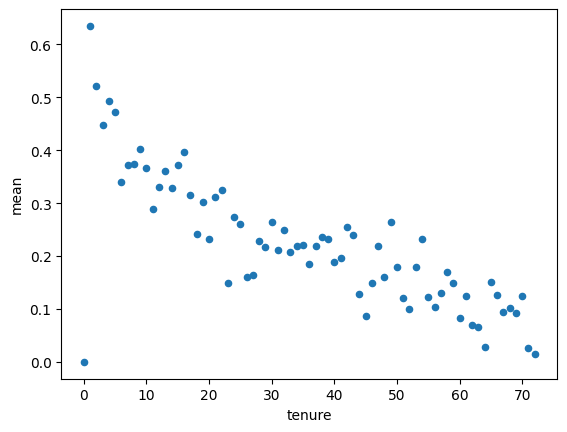

In [133]:
df_train_val.groupby("tenure")["churn"].agg(["mean","std"]).reset_index().plot(x='tenure',
                                                                         y='mean',
                                                                        kind='scatter')